In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import math
from collections import Counter

pd.set_option('display.max_columns', None)
import warnings
warnings.filterwarnings("ignore")

# Data downloading

### Download the data from Kaggle (for Colab)

In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

# import os

# !mkdir -p ~/.kaggle
# !cp "/content/drive/MyDrive/Colab Notebooks/kaggle.json" ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json

# !kaggle competitions download -c home-credit-default-risk --force

In [3]:
# import zipfile

# zip_path = "/content/home-credit-default-risk.zip"
# extract_dir = "/content/home-credit-data"

# # Создаём папку для распаковки
# os.makedirs(extract_dir, exist_ok=True)

# # Распаковка
# with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# # Проверим, что распаковано
# os.listdir(extract_dir)

In [4]:
# For Colab
# app_train = pd.read_csv(f'{extract_dir}/application_train.csv')
# app_test = pd.read_csv(f'{extract_dir}/application_test.csv')

In [5]:
app_train = pd.read_csv('../Data/application_train.csv')
app_test = pd.read_csv('../Data/application_test.csv')

In [6]:
print ("Формат обучающей выборки:", app_train.shape)
print ("Формат тестовой выборки:", app_test.shape)

Формат обучающей выборки: (307511, 122)
Формат тестовой выборки: (48744, 121)


# EDA

## Counting NaNs:

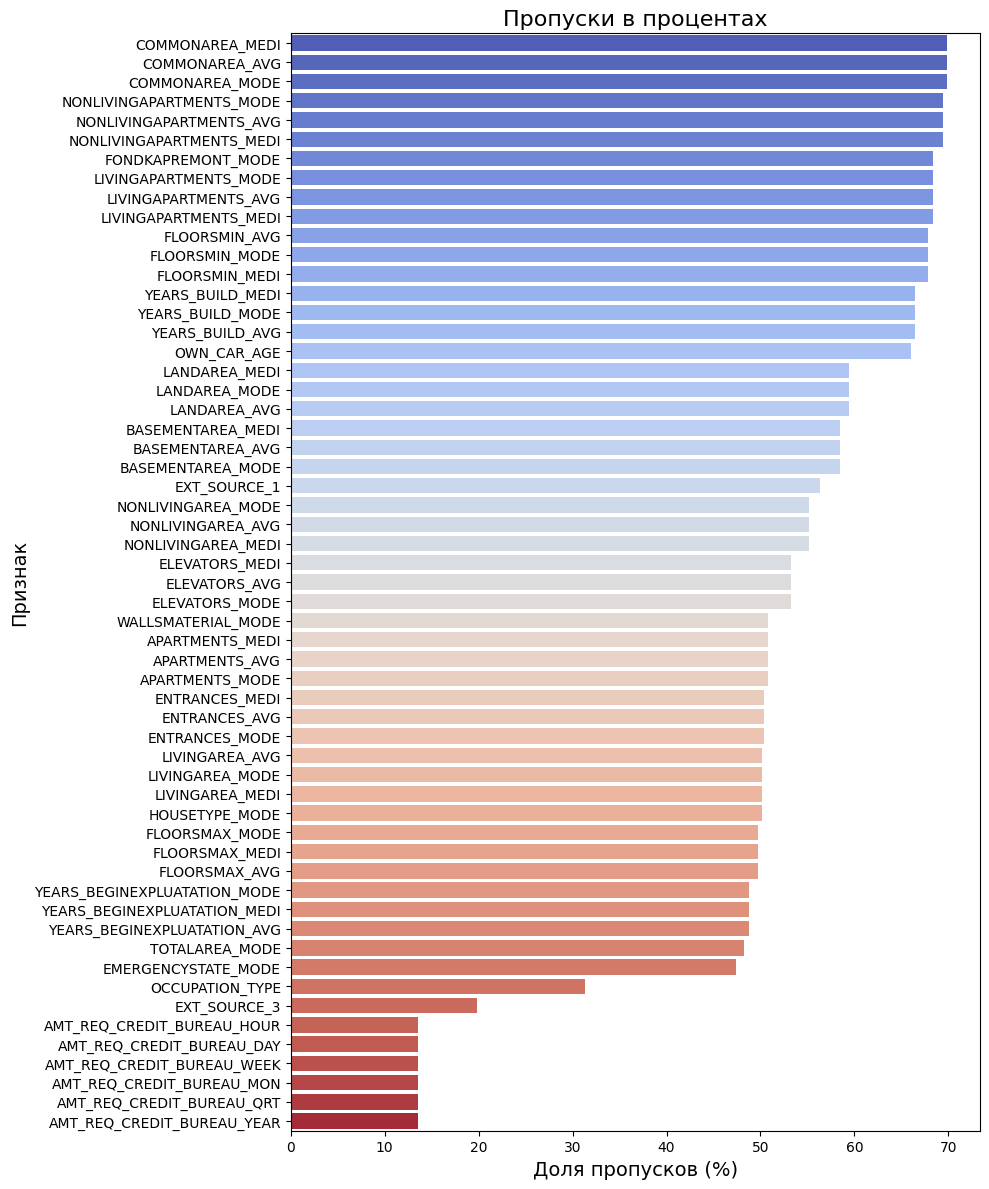

In [7]:
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 1]

plt.figure(figsize=(10, 12))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette='coolwarm', hue=None)
plt.title("Пропуски в процентах", fontsize=16)
plt.xlabel("Доля пропусков (%)", fontsize=14)
plt.ylabel("Признак", fontsize=14)
plt.tight_layout()
plt.show()

Можно заметить, что довольно большая часть датасета имеет пропуски (до 70%). В разделе Feature Engineering будем искать решение этой проблемы

## Check for the outliers

In [8]:
def plot_boxplots(features_list, df):
    n = len(features_list)
    cols = 3
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = axes.flatten()

    for i, feature in enumerate(features_list):
        Q1 = df[feature].quantile(0.25)
        Q3 = df[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_whisker = Q1 - 1.5 * IQR
        upper_whisker = Q3 + 1.5 * IQR

        outliers = app_train[
            (df[feature] < lower_whisker) |
            (df[feature] > upper_whisker)
        ]

        sns.boxplot(x=df[feature], ax=axes[i], label=f'Количество выбросов: {outliers.shape[0]}\nДоля выбросов: {outliers.shape[0] / app_train.shape[0]:.2%}')
        axes[i].set_title(feature)

    plt.tight_layout()
    plt.show()


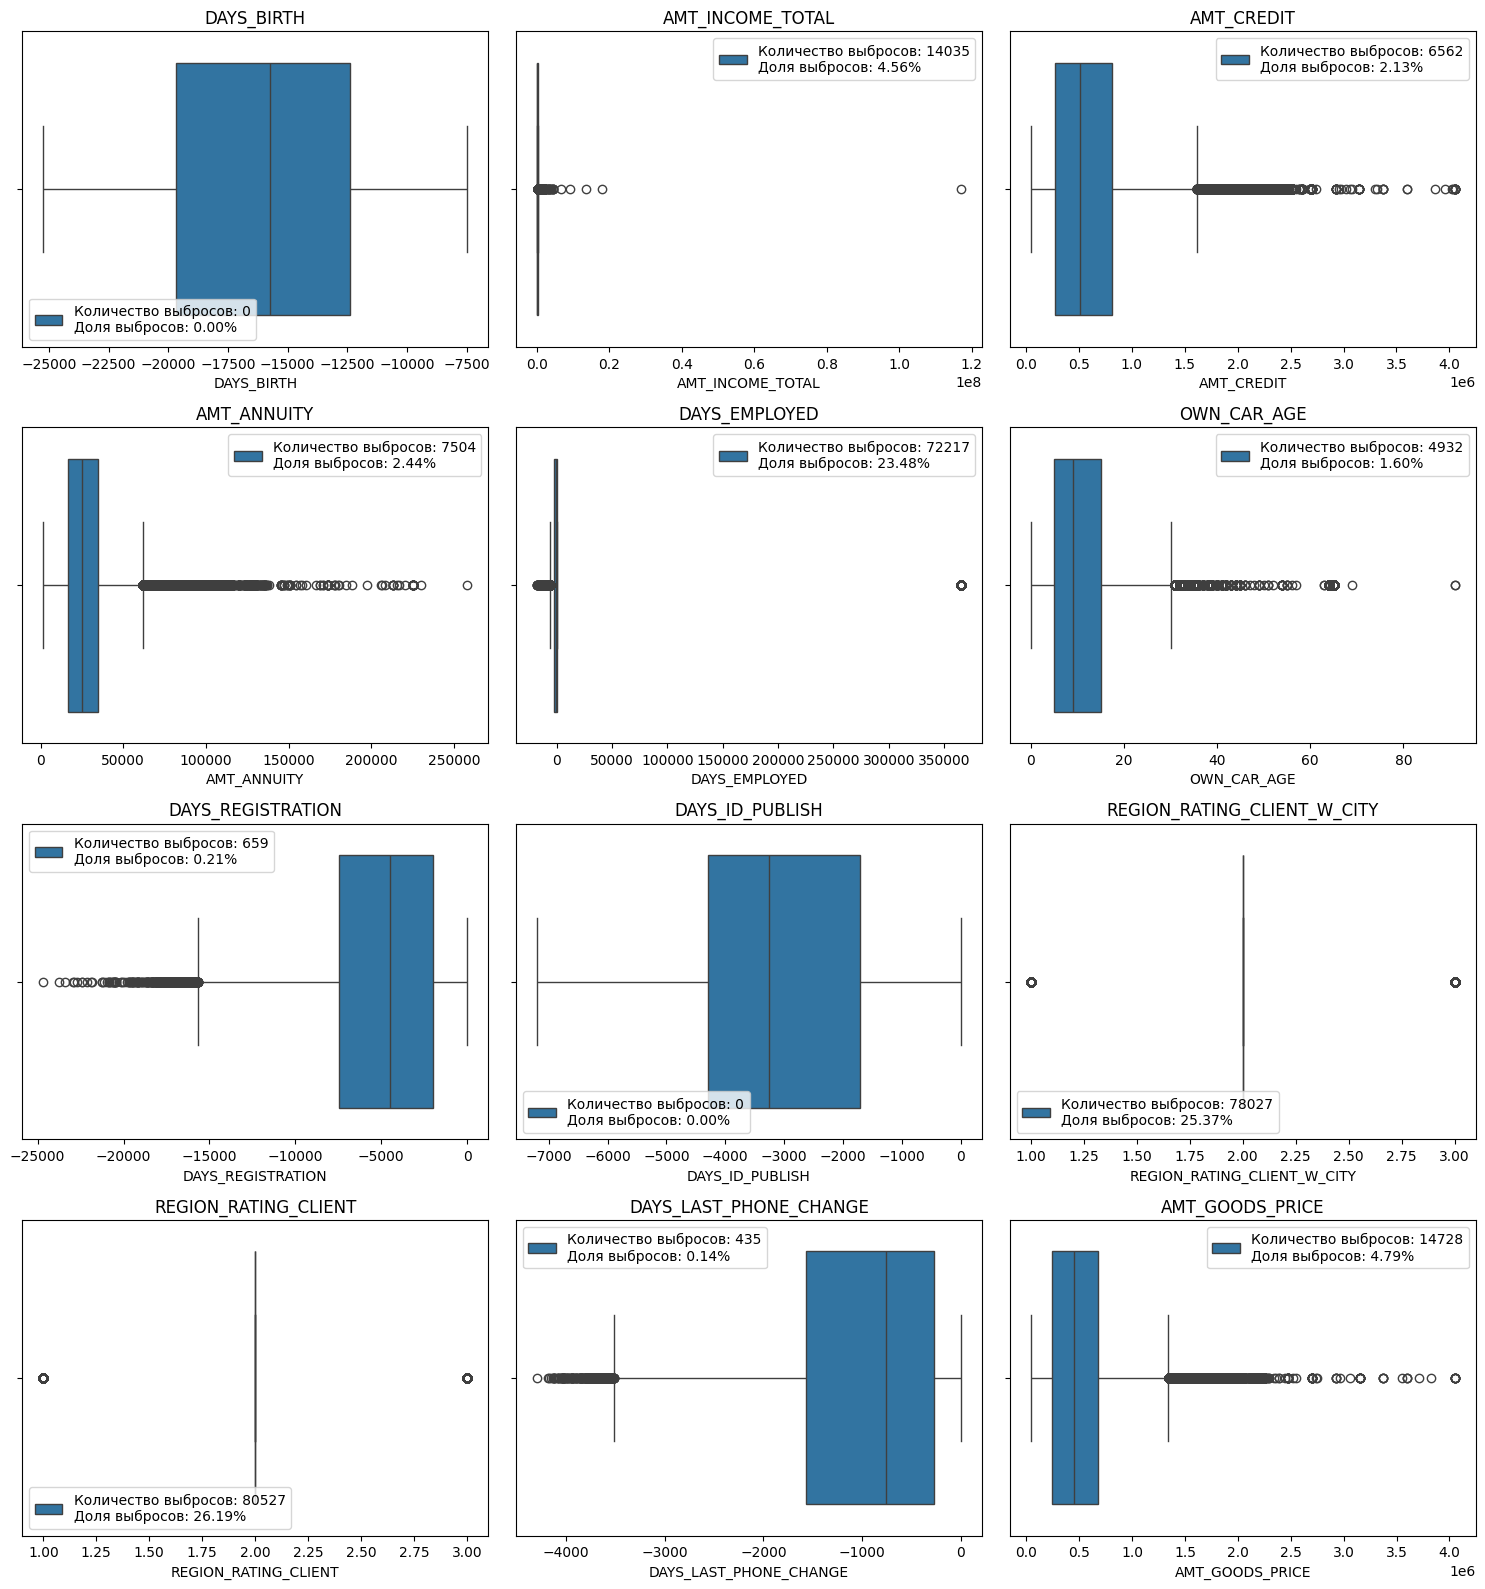

In [9]:
plot_boxplots(
    [
        'DAYS_BIRTH',
        'AMT_INCOME_TOTAL',
        'AMT_CREDIT',
        'AMT_ANNUITY',
        'DAYS_EMPLOYED',
        'OWN_CAR_AGE',
        'DAYS_REGISTRATION',
        'DAYS_ID_PUBLISH',
        'REGION_RATING_CLIENT_W_CITY',
        'REGION_RATING_CLIENT',
        'DAYS_LAST_PHONE_CHANGE',
        'AMT_GOODS_PRICE'
    ],
    app_train
)

Исходя из данных графиков, можно точно сказать, что выбросами являются:

1) AMT INCOME_TOTAL - Ежегодный доход в 120 млн. рублей

2) DAYS_EMPLOYED - Опыт работы на текущем месте работы около 350 тыс. дней

Остальные значения хоть и выбиваются за пределы "усов", но имеют реальное обоснование и их удаление будет неправильным.

## Target distribution

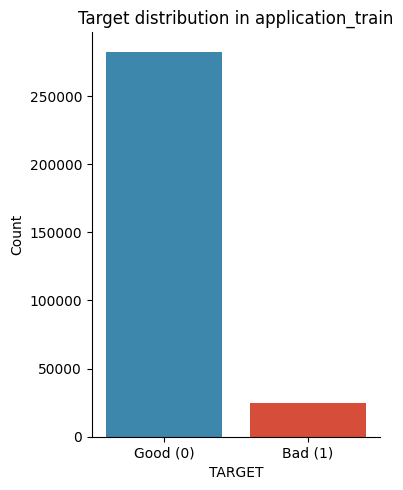

In [10]:
counts = app_train['TARGET'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(4,5))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette=['#2b8cbe','#f03b20'])

ax.set_xticklabels(['Good (0)','Bad (1)'])
ax.set_ylabel('Count')
ax.set_title('Target distribution in application_train')

sns.despine(left=False)
plt.tight_layout()
plt.show()

Можно увидеть явный дисбаланс классов, что будет сильно мешать нашей модели правильно обучаться.

## Coefficients of correlation

Воспользуемся коэффициентами корреляции Пирсона, хоть это и не лучший метод для подбора фичей, однако, он прост и позволяет составить первоначальное представление о данных.

In [11]:
# Select only numeric columns before calculating correlations
correlations = app_train.select_dtypes(include=np.number).corr()['TARGET'].sort_values()

print('Наивысшая позитивная корреляция:\n', correlations.tail(15))
print('\nНаивысшая негативная коррелация:\n', correlations.head(15))

Наивысшая позитивная корреляция:
 DEF_60_CNT_SOCIAL_CIRCLE       0.031276
DEF_30_CNT_SOCIAL_CIRCLE       0.032248
LIVE_CITY_NOT_WORK_CITY        0.032518
OWN_CAR_AGE                    0.037612
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
TARGET                         1.000000
Name: TARGET, dtype: float64

Наивысшая негативная коррелация:
 EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              

Таким образом, все данные слабо коррелируют с таргетом. Однако выделяются возраст и некие "внешние источники данных", рассмотрим их подробнее.

### Функция для расчета Default Rate, WOE, Information Value

**Weight of Evidence (WOE)** — показатель, отражающий риск дефолта в отдельном бине признака.  
Рассчитывается как логарифм отношения доли «хороших» клиентов к доле «плохих»:

WOE = ln(Good / Bad)

- WOE > 0 — бин менее рискованный, чем в среднем по выборке  
- WOE < 0 — бин более рискованный  
- WOE ≈ 0 — риск сопоставим со средним

**Information Value (IV)** — агрегированная мера предсказательной силы признака в целом.  
Рассчитывается как сумма вкладов всех бинов:

IV = Σ (Goodᵢ − Badᵢ) · WOEᵢ

Чем выше IV, тем лучше признак разделяет «хороших» и «плохих» заемщиков.

**Интерпретация IV:**
- IV < 0.02 — неинформативный признак  
- 0.02–0.1 — слабый  
- 0.1–0.3 — средний  
- 0.3–0.5 — сильный  
- IV > 0.5 — возможная утечка данных

Выбираем признак, разделяем людей на равные по количеству группы при помощи pd.qcut()

Комплексно оцениваем, насколько каждая фича помогает нам выявлять таргет

In [12]:
# Вспомогательная функция для получения названий интервалов из индекса датафрейма, образованного методом pd.cut()
def get_interval_name(df, interval_round=None):
    output = []

    for val in df.index:
        if isinstance(val, pd.Interval):
            if interval_round is not None:
                left = round(val.left, interval_round)
                right = round(val.right, interval_round)
            else:
                left = val.left
                right = val.right
            output.append(f'{left} - {right}')
        else:
            output.append(str(val))

    return output

In [13]:
# Вспомогательная функция для получения цветовой палитры на основе значений серии и заданной карты цветов
def get_palette(df, colormap_name, reversed=False):
    norm = mpl.colors.Normalize(
        vmin=df.min(),
        vmax=df.max()
    )

    cmap = mpl.colormaps[colormap_name]

    palette = [cmap(norm(v)) for v in df]

    if reversed == True:
        palette = palette[::-1]

    return palette

In [14]:
def plot_df_woe_iv(
                feature_name,
                df=app_train,
                bins_dict={'Count': 30, 'Default_Rate': 10, 'WOE & IV': 7},
                x_size=10,
                y_size=7,
                interval_round=None,
                use_raw_values=False
            ):
    
    fig, axes = plt.subplots(2, 2, figsize=(x_size, y_size))
    
    df_plot = df[[feature_name, 'TARGET']].dropna()

    # ---------- DEFAULT RATE ----------
    if use_raw_values:
        df_plot['BIN_DR'] = df_plot[feature_name]
    else:
        df_plot['BIN_DR'] = pd.cut(
            df_plot[feature_name],
            bins=bins_dict['Default_Rate'],
            duplicates='drop'
        )

    df_default_rate = (
        df_plot
        .groupby('BIN_DR', observed=True)
        .agg(
            Count=('TARGET', 'count'),
            Default_Rate=('TARGET', 'mean')
        )
    )

    sns.histplot(
        df_plot[feature_name],
        ax=axes[0,0],
        bins=bins_dict['Count'],
        color=plt.cm.Set2(np.random.randint(0, 8))
    )

    sns.barplot(
        x=get_interval_name(df_default_rate, interval_round),
        y=df_default_rate['Default_Rate'],
        ax=axes[0,1],
        palette=get_palette(df_default_rate['Default_Rate'], 'RdYlGn', reversed=True)
    )

    axes[0,0].set_title('Count')
    axes[0,1].set_title('Default Rate')
    axes[0,1].set_xlabel(feature_name)
    axes[0,0].tick_params(axis='x', rotation=45)
    axes[0,1].tick_params(axis='x', rotation=45)

    # ---------- WOE & IV ----------
    if use_raw_values:
        df_plot['BIN_WOE'] = df_plot[feature_name]
    else:
        df_plot['BIN_WOE'] = pd.qcut(
            df_plot[feature_name],
            q=bins_dict['WOE & IV'],
            duplicates='drop'
        )

    df_woe = (
        df_plot
        .groupby('BIN_WOE', observed=True)['TARGET']
        .value_counts()
        .unstack(fill_value=0)
        .rename(columns={0: 'Good', 1: 'Bad'})
    )

    eps = 1e-9

    df_woe = df_woe.assign(
        Prop_Good=lambda x: x['Good'] / x['Good'].sum(),
        Prop_Bad=lambda x: x['Bad'] / x['Bad'].sum(),
        WOE=lambda x: np.log((x['Prop_Good'] + eps) / (x['Prop_Bad'] + eps)),
        IV=lambda x: (x['Prop_Good'] - x['Prop_Bad']) * x['WOE']
    )

    iv_total = df_woe['IV'].sum()

    sns.barplot(
        x=get_interval_name(df_woe, interval_round),
        y=df_woe['WOE'],
        ax=axes[1,0],
        palette=get_palette(df_woe['WOE'], 'RdYlGn')
    )
    axes[1,0].axhline(0, linestyle='--')
    axes[1,0].set_title('WOE')

    sns.barplot(
        x=get_interval_name(df_woe, interval_round),
        y=df_woe['IV'],
        ax=axes[1,1],
        palette=get_palette(df_woe['IV'], 'PiYG')
    )
    axes[1,1].set_title(f'IV | Total = {iv_total:.4f}')
    axes[1,0].set_xlabel(feature_name)
    axes[1,1].set_xlabel(feature_name)
    axes[1,0].tick_params(axis='x', rotation=45)
    axes[1,1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


### Возраст

Сделаем возраст положительным и переведем в года для удобства:

In [15]:
app_train['AGE_YEARS'] = abs(app_train['DAYS_BIRTH']) / 365
app_test['AGE_YEARS'] = abs(app_test['DAYS_BIRTH']) / 365

app_train.drop('DAYS_BIRTH', axis=1, inplace=True)
app_test.drop('DAYS_BIRTH', axis=1, inplace=True)

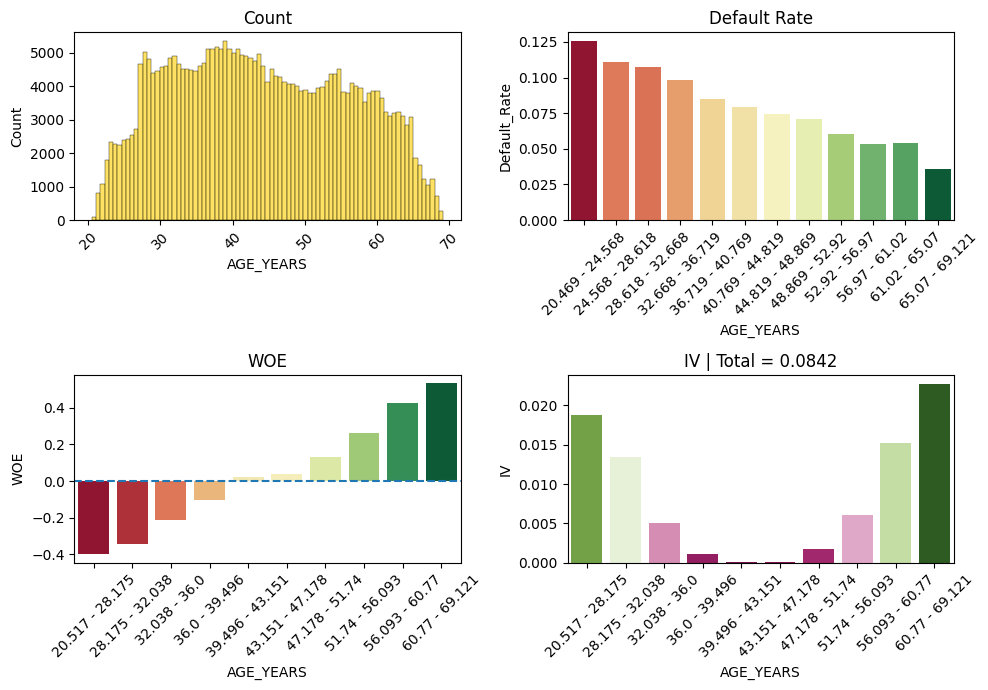

In [16]:
plot_df_woe_iv(
        'AGE_YEARS',
        df=app_train,
        bins_dict={
                'Count': 'auto',
                'Default_Rate': 12,
                'WOE & IV': 10
        },
        interval_round=None,
        x_size=10,
        y_size=7
)

**Count** & **Default Rate**

- Видно, что нет явных выбросов, распределение возраста довольно обычное, однако, доля невозвратов выше для молодых людей и снижается с ростом возраста.

- Это не повод отказывать молодым людям в кредите полностью, такая "рекомендация" приведет лишь к потере доходов и довольно значимой части рынка для банка. Это повод задуматься о более тщательном их ведении, оценке и контроле.

**WOE**
- В младших возрастных бинах WOE отрицательный — повышенный риск.
- С ~40–45 лет WOE становится положительным и растёт, отражая более надёжный профиль старших клиентов.

**IV**
- IV ≈ 0.08 — признак слабой–средней предсказательной силы.
- Основной вклад в IV дают крайние возрастные группы, где различия в риске максимальны.

### Внешние источники

Посмотрим внимательнее на "внешние источники данных" и их корреляцию.

In [17]:
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']]
ext_data_corrs = ext_data.corr() # type: ignore
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AGE_YEARS
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
AGE_YEARS,-0.078239,0.600610,0.091996,0.205478,1.000000


Удобнее будет отобразить корреляцию в heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

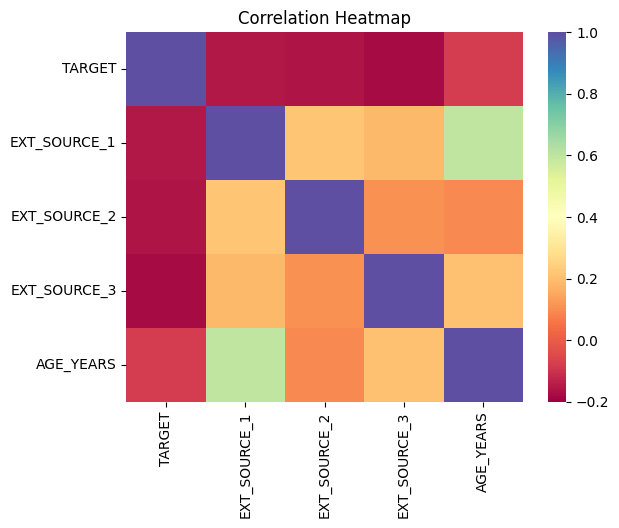

In [18]:
sns.heatmap(ext_data_corrs, cmap=mpl.colormaps['Spectral'], vmin=-0.2)
plt.title('Correlation Heatmap')

Как видно, все источники показывают негативную корреляцию с таргетом. Посмотрим на распределение Default Rate, WOE & IV

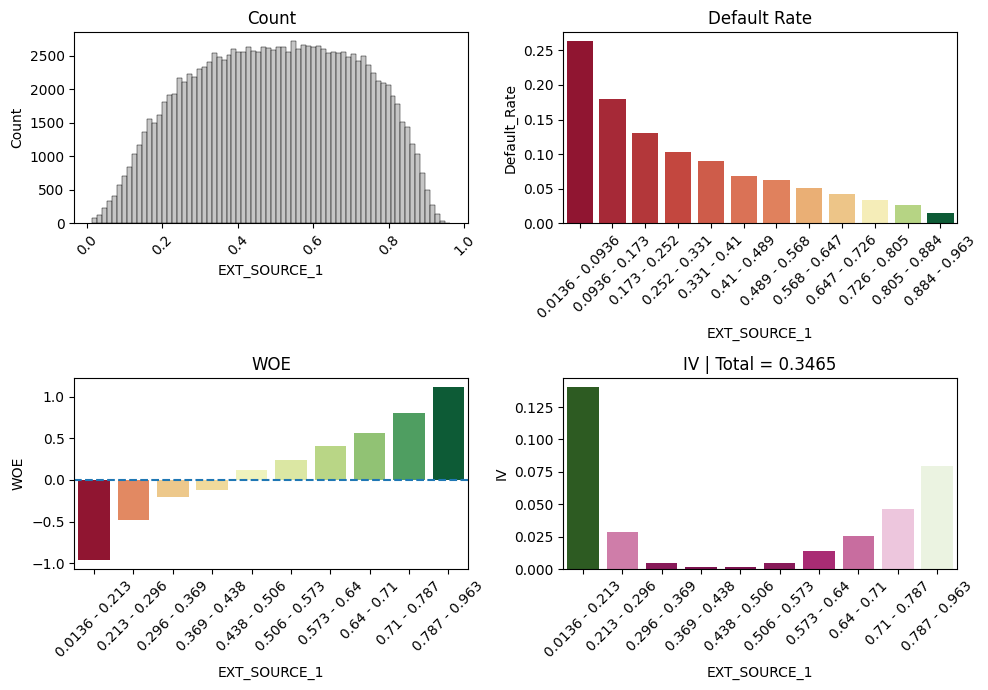

In [19]:
plot_df_woe_iv(
        'EXT_SOURCE_1',
        df=app_train,
        bins_dict={
                'Count': 'auto',
                'Default_Rate': 12,
                'WOE & IV': 10
        },
        interval_round=4,
        x_size=10,
        y_size=7
)

Вывод: пока что лучший признак как по графику WOE, так и по IV = 0.03465, хотя по корреляция Пирсона показала не самое высокое значение.

Расссотрим далее **EXT_SOURCE_2**

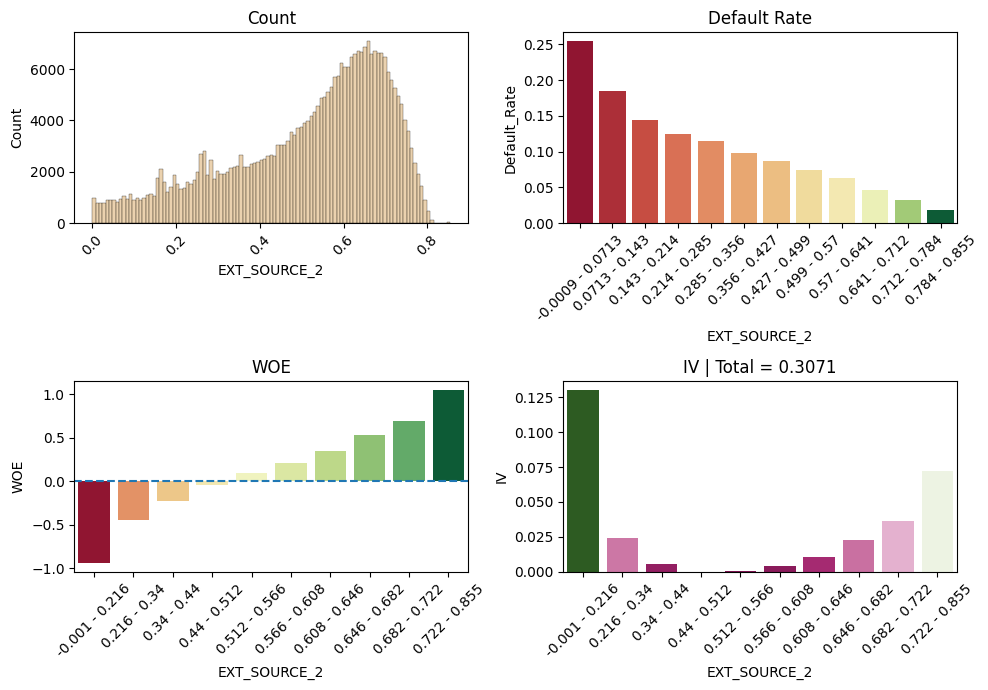

In [20]:
plot_df_woe_iv(
        'EXT_SOURCE_2',
        df=app_train,
        bins_dict={
                'Count': 'auto',
                'Default_Rate': 12,
                'WOE & IV': 10
        },
        interval_round=4,
        x_size=10,
        y_size=7
)

Вывод: аналогично с первым внешним источником.

Последний: **EXT_SOURCE_3**

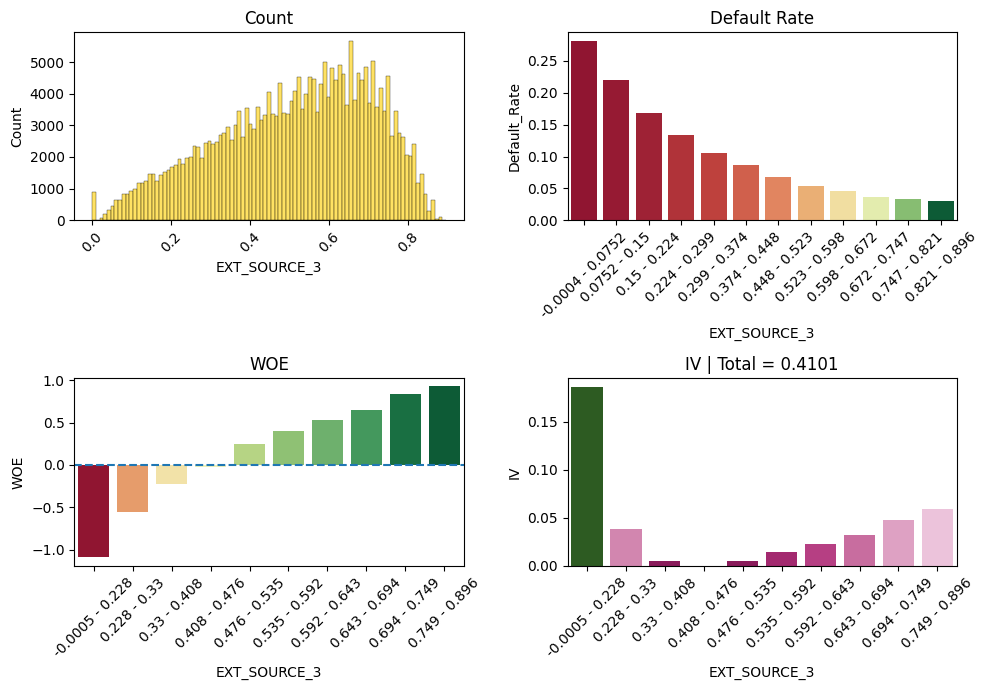

In [21]:
plot_df_woe_iv(
        'EXT_SOURCE_3',
        df=app_train,
        bins_dict={
                'Count': 'auto',
                'Default_Rate': 12,
                'WOE & IV': 10
        },
        interval_round=4,
        x_size=10,
        y_size=7
)

Вывод: лучший признак по IV = 0.4101

### Distribution by credit amount

Рассмотрим зависимость целевой переменной от размера кредита

In [22]:
app_train['AMT_CREDIT'] = app_train['AMT_CREDIT'] / 1000
app_test['AMT_CREDIT'] = app_test['AMT_CREDIT'] / 1000

In [23]:
app_train['AMT_CREDIT'].describe()

count    307511.000000
mean        599.026000
std         402.490777
min          45.000000
25%         270.000000
50%         513.531000
75%         808.650000
max        4050.000000
Name: AMT_CREDIT, dtype: float64

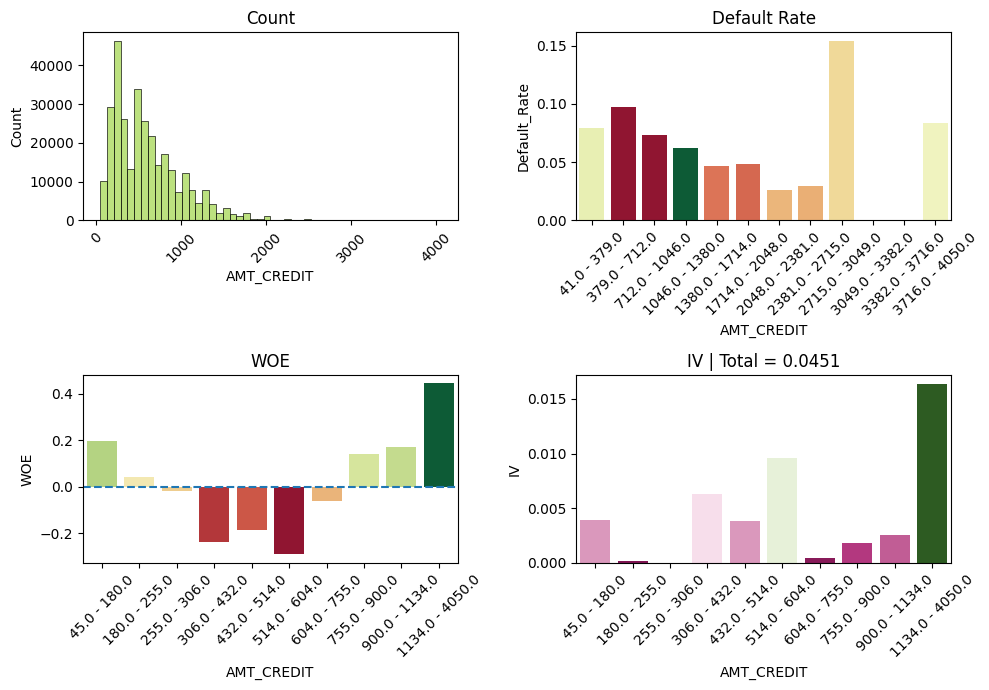

In [24]:
plot_df_woe_iv(
        'AMT_CREDIT',
        df=app_train,
        bins_dict={
                'Count': 50,
                'Default_Rate': 12,
                'WOE & IV': 10
        },
        interval_round=0,
        x_size=10,
        y_size=7
)

Основные выводы из графика:

**1. Зона повышенного риска (средние суммы кредитов)**  
В диапазоне примерно 300–600 тыс. наблюдается повышенная вероятность дефолта.  
Наиболее рискованный сегмент — 513–604 тыс., где значение WOE достигает минимума.

**2. Относительно безопасные крупные кредиты**  
Для сумм свыше 1.1 млн фиксируется резкий рост WOE.  
Это, как правило, связано с более строгим скорингом и отбором заемщиков с высоким доходом, что снижает относительный риск дефолта.

**3. Парадокс малых кредитов**  
Небольшие займы (до 180 тыс.) имеют положительный WOE, что указывает на их сравнительно низкий риск.  
Вероятная причина — более высокая платежеспособность по таким обязательствам даже при ухудшении финансового положения заемщика.

### Distribution by working experience

In [25]:
# число 365243 используется как заглушка для отсутствующего стажа
app_train['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
app_train['DAYS_EMPLOYED'] = abs(app_train['DAYS_EMPLOYED'])
app_train['YEARS_EMPLOYED'] = app_train['DAYS_EMPLOYED'] / 365.25

app_test['DAYS_EMPLOYED'].replace(365243, np.nan, inplace=True)
app_test['DAYS_EMPLOYED'] = abs(app_test['DAYS_EMPLOYED'])
app_test['YEARS_EMPLOYED'] = app_test['DAYS_EMPLOYED'] / 365.25

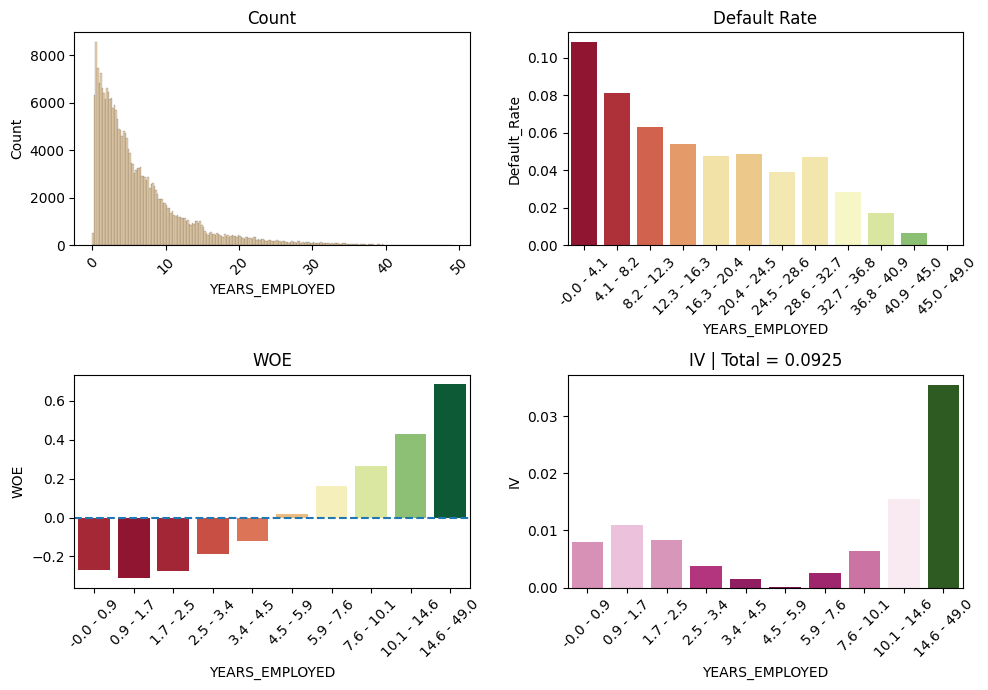

In [26]:
plot_df_woe_iv(
        'YEARS_EMPLOYED',
        df=app_train,
        bins_dict={
                'Count': 'auto',
                'Default_Rate': 12,
                'WOE & IV': 10
        },
        interval_round=1,
        x_size=10,
        y_size=7
)

**Прямая корреляция с надежностью:**

Мы видим четкую линейную тенденцию: чем дольше человек работает на текущем месте, тем выше его WOE, а значит — тем ниже риск дефолта

**Fun Fact:**

Любопытно, что совсем новички (до 333 дней) рискованны чуть меньше, чем те, кто проработал год, что может быть связано с особенностями прохождения испытательного срока или спецификой найма.

### Distribution by population density

REGION_POPULATION_RELATIVE – Normalized population of region where client lives (higher number means the client lives in more populated region)

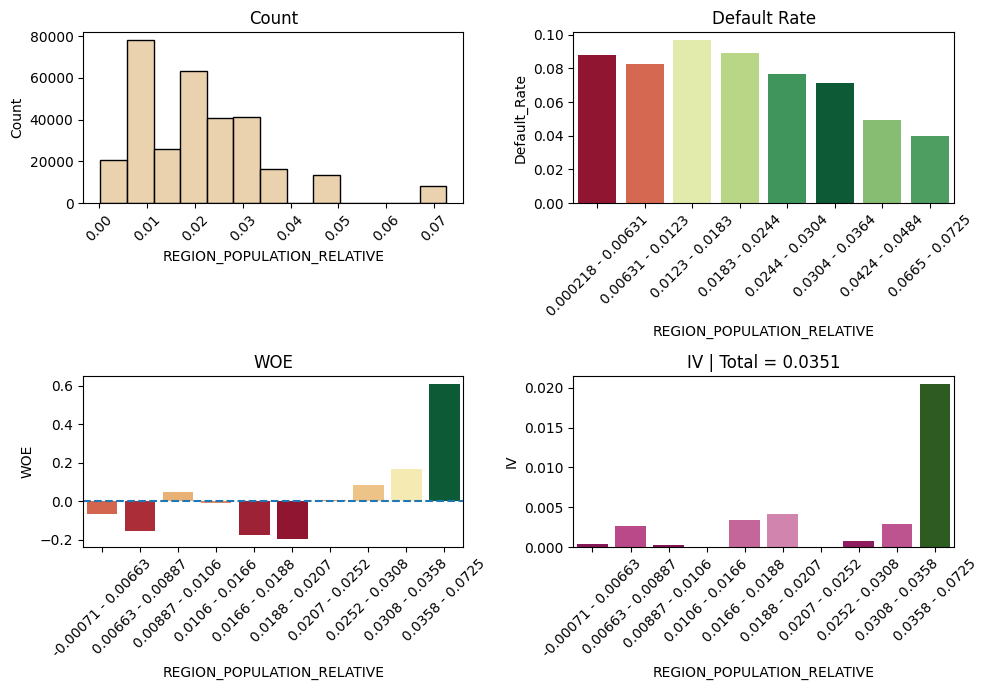

In [27]:
plot_df_woe_iv(
        'REGION_POPULATION_RELATIVE',
        df=app_train,
        bins_dict={
                'Count': 13,
                'Default_Rate': 12,
                'WOE & IV': 10
        },
        interval_round=None,
        x_size=10,
        y_size=7
)

Вывод: с точки зрения пользы для отличия хороших и плохих клиентов - не самый лучший признак

## Other features exploration

Рассмотрим более подробно другие признаки и их зависимость от целевой переменной

In [28]:
# application_train = pd.read_csv('Data/application_train.csv')
# application_test = pd.read_csv('Data/application_test.csv')

In [29]:
def plot_stats(feature, label_rotation=0):
    sns.set_color_codes("pastel")

    feat_counts = app_train[feature].value_counts()
    count_df = pd.DataFrame({feature: feat_counts.index,'Loan count': feat_counts.values})

    # Counting target == 1 cats
    perc_df = app_train[[feature, 'TARGET']].groupby([feature], as_index=False).mean()
    perc_df.sort_values(by='TARGET', ascending=False, inplace=True)

    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,6))

    s = sns.barplot(ax=ax1, x = feature, y="Loan count", data=count_df, palette='Set2')
    s.set_xticklabels(s.get_xticklabels(), rotation=label_rotation)

    s = sns.barplot(ax=ax2, x = feature, y='TARGET', order=perc_df[feature], data=perc_df, palette='Set2')
    s.set_xticklabels(s.get_xticklabels(), rotation=label_rotation)

    plt.ylabel('Default Rate', fontsize=10)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.show()

### Contract type

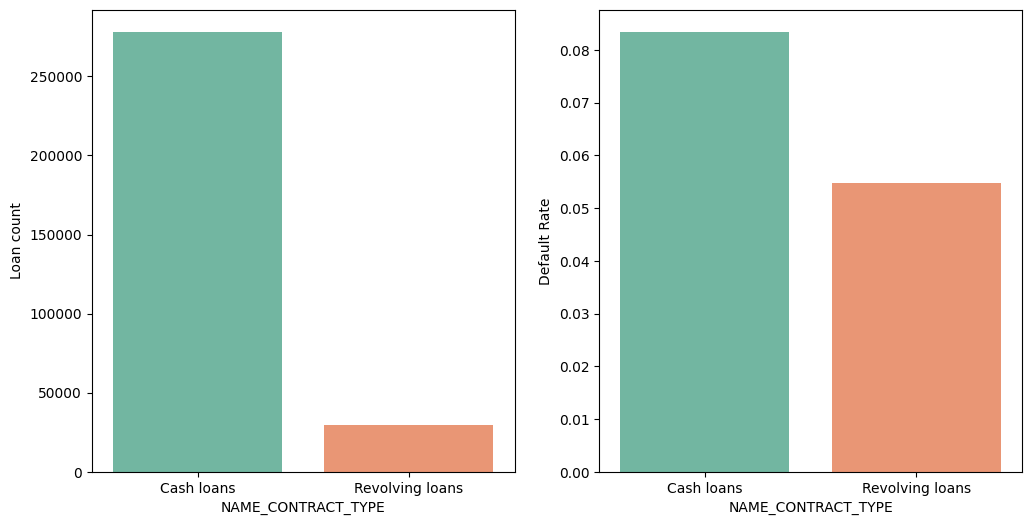

In [30]:
plot_stats('NAME_CONTRACT_TYPE')

Интересно, что револьверные кредиты (вероятно, овердрафты или что-то вроде того) составляют меньше 10% от общего количества займов. В то же время процент невозврата сравнительно немал. Хороший повод пересмотреть методику работы с этими займами, а может быть и отказаться от них вовсе.

### Client Gender

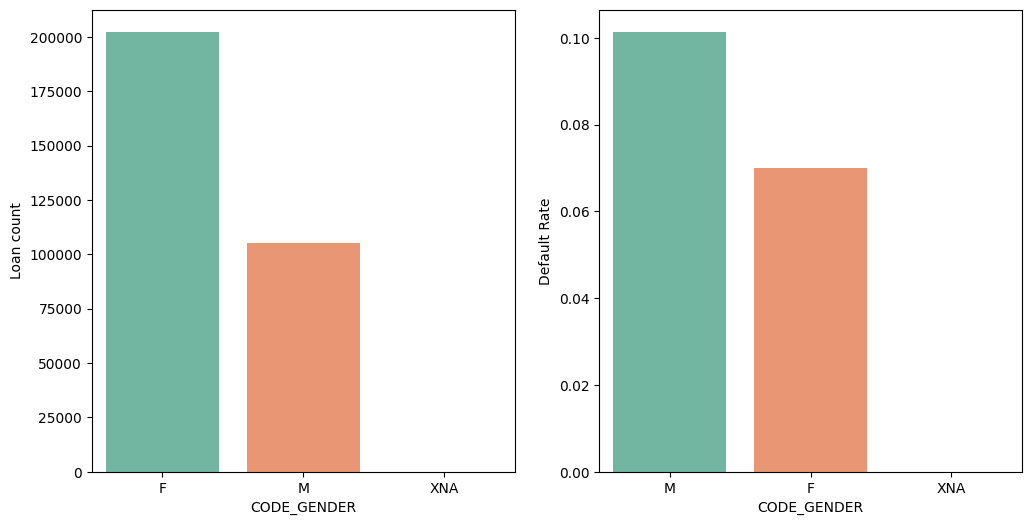

In [31]:
plot_stats('CODE_GENDER')

Женщин-клиентов почти вдвое больше мужчин, при этом мужчины показывают гораздо более высокий риск.

### Own Car or Realty

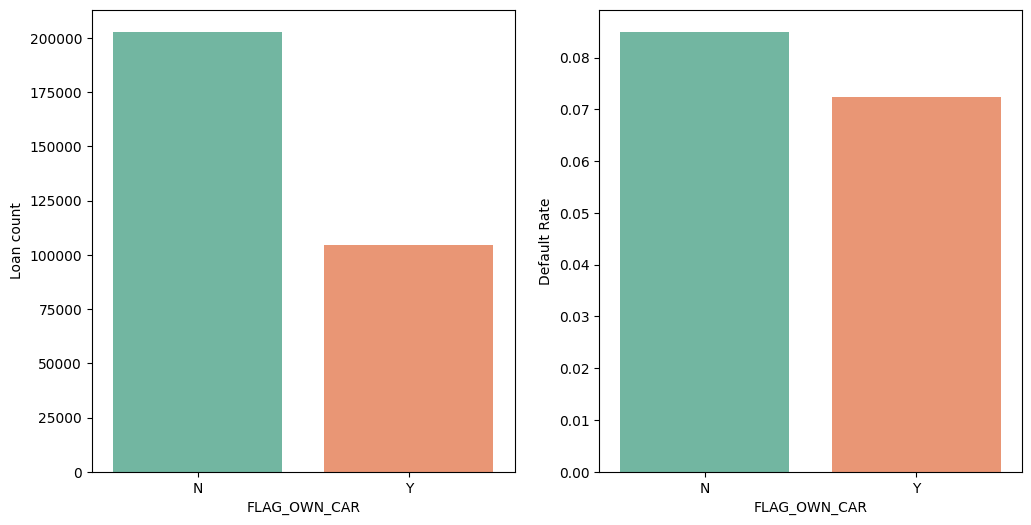

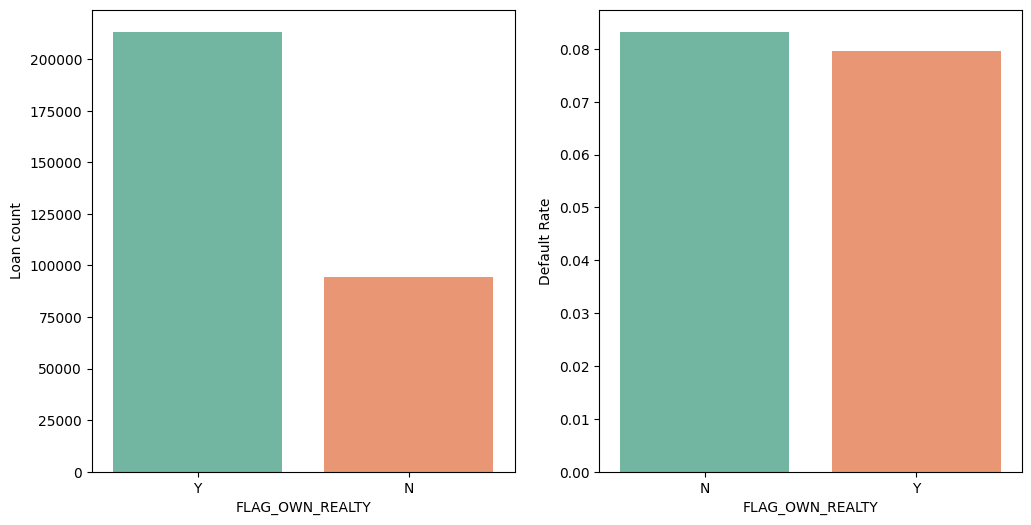

In [32]:
plot_stats('FLAG_OWN_CAR')
plot_stats('FLAG_OWN_REALTY')

**Car**

Клиентов, не имеющих автомобиля, в два раза больше, чем тех, у кого он есть. Риск по ним практически одинаковый, клиенты с машиной платят чуть лучше.

**Realty**

По недвижимости обратная картина - клиентов без нее вдвое меньше. Риск по владельцам недвижимости также чуть меньше.

### Family status

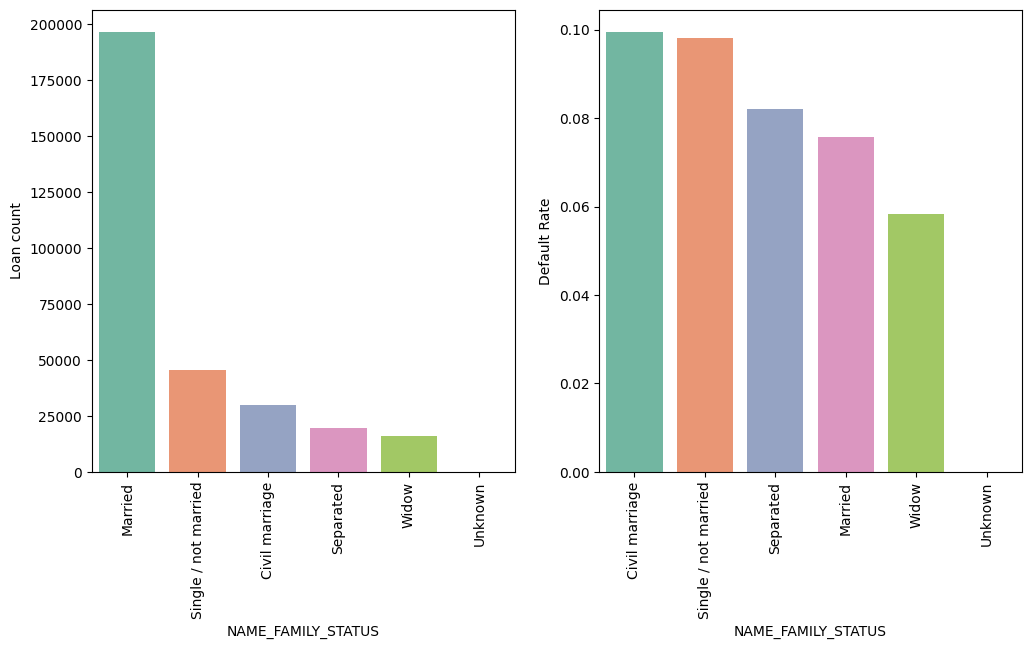

In [33]:
plot_stats('NAME_FAMILY_STATUS', 90)

В то время как большинство клиентов состоит в браке, ниаболее рискованы клиенты в гражданском браке и одинокие. Вдовцы показывают минимальный риск.

### Children count

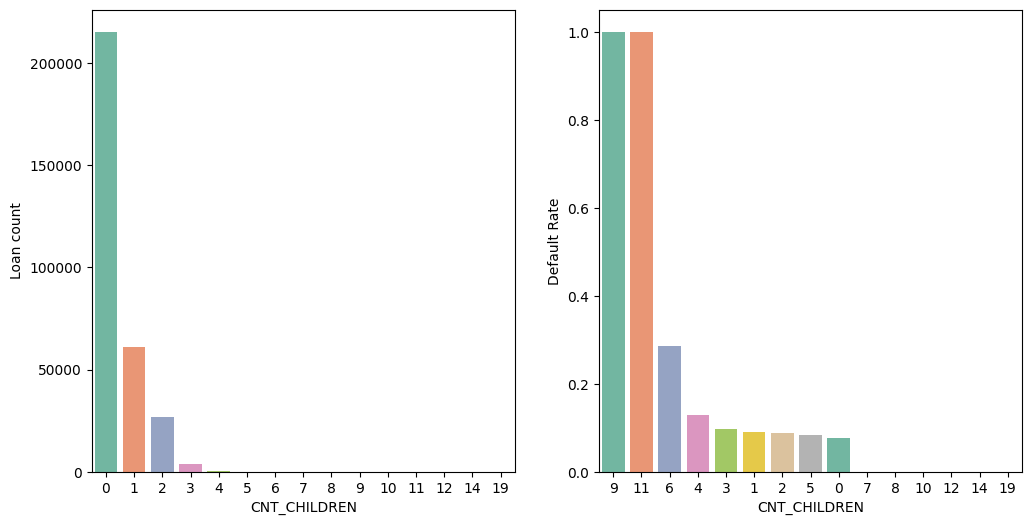

In [34]:
plot_stats('CNT_CHILDREN')

Большинство клиентов бездетны. При этом клиенты с 9 и 11 детьми показывют полный невозврат. Однако необходимо проверить, насколько эти данные статистически значимы:

In [35]:
app_train.CNT_CHILDREN.value_counts().tail()

CNT_CHILDREN
9     2
12    2
10    2
19    2
11    1
Name: count, dtype: int64

Как показывает подсчет значений, эти данные не имеют веса - всего по 2 клиента обеих категорий (9 и 11 детей). Однако, все 4 вышли в дефолт, равно как и половина клиентов с 6 детьми.

Поэтому объединим всех клиентов, имеющих 4 и более детей в отдельную категорию 4+:

In [36]:
app_train[app_train['CNT_CHILDREN'] > 3]['CNT_CHILDREN'] = 4
app_test[app_test['CNT_CHILDREN'] > 3]['CNT_CHILDREN'] = 4

### Family members count

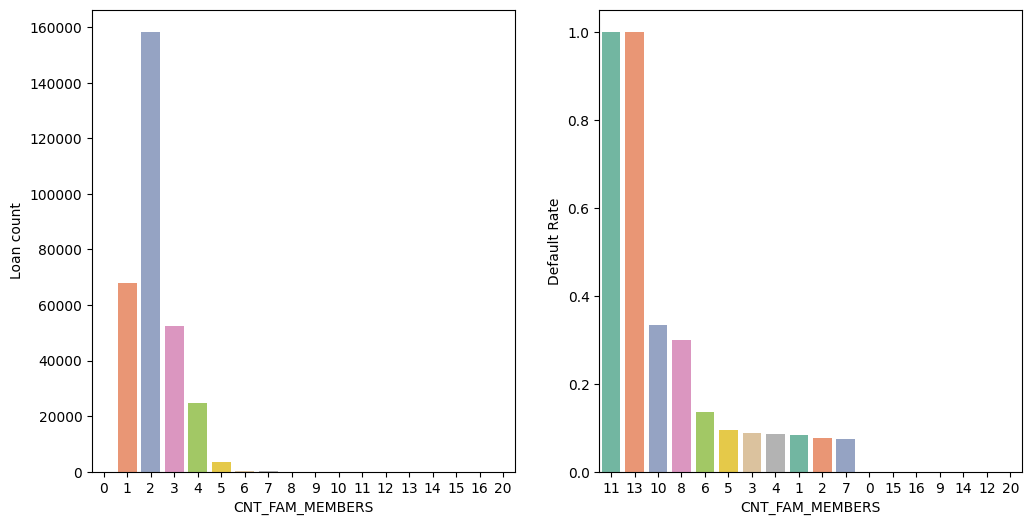

In [37]:
app_train.CNT_FAM_MEMBERS = app_train.CNT_FAM_MEMBERS.fillna(0).astype(int)
app_test.CNT_FAM_MEMBERS = app_test.CNT_FAM_MEMBERS.fillna(0).astype(int)
plot_stats('CNT_FAM_MEMBERS')

In [38]:
app_train.CNT_FAM_MEMBERS.value_counts().tail()

CNT_FAM_MEMBERS
20    2
16    2
13    1
15    1
11    1
Name: count, dtype: int64

Наблюдается та же закономерность — чем меньше членов в семье, тем выше вероятность возврата кредита. Для решения проблем с малочисленными классами, поступим также как и с CNT_CHILDREN

In [39]:
app_train[app_train['CNT_FAM_MEMBERS'] > 5]['CNT_FAM_MEMBERS'] = 6
app_test[app_test['CNT_FAM_MEMBERS'] > 5]['CNT_FAM_MEMBERS'] = 6

### Income type (Пересмотреть)

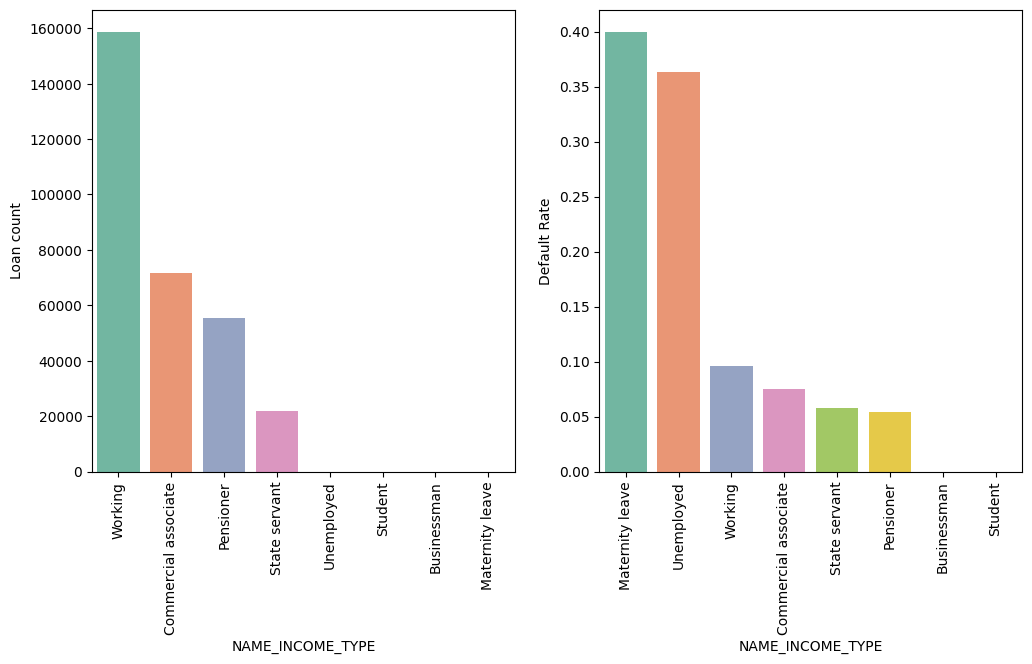

In [40]:
plot_stats('NAME_INCOME_TYPE', 90)

In [41]:
app_train.NAME_INCOME_TYPE.value_counts()

NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64

В связи с очень малым количеством людей в классах **['Unemployed', 'Student', 'Businessman', 'Maternity leave']**, объединим их в одну группу - other, дабы уменьшить переобучение модели

### Working sphere

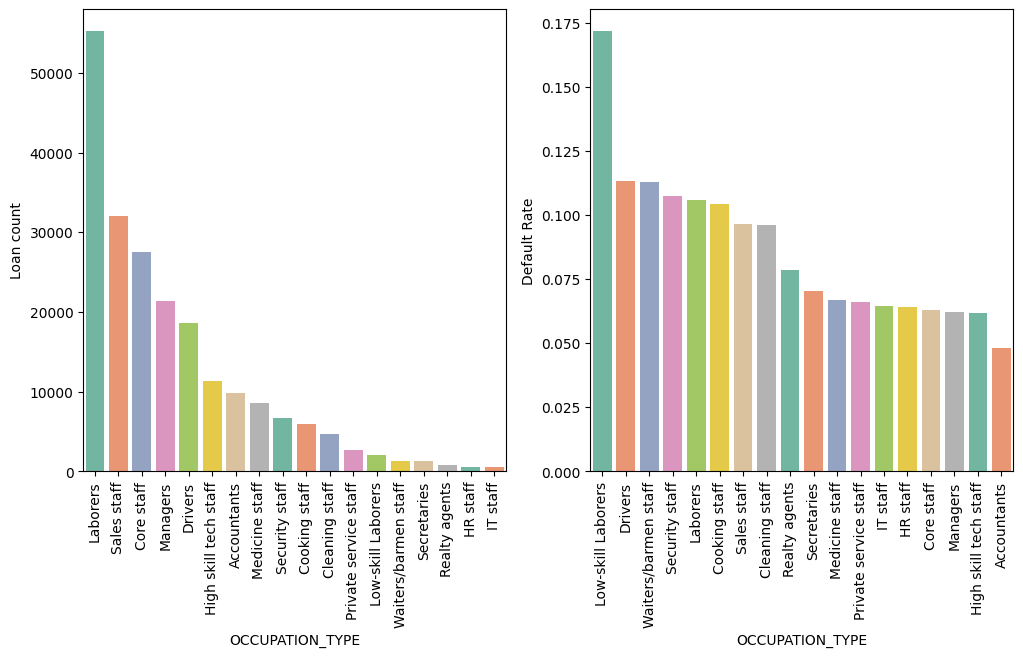

In [42]:
plot_stats('OCCUPATION_TYPE', 90)

In [43]:
app_train.OCCUPATION_TYPE.value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

Здесь вызывают интерес водители и сотрудники безопасности, которые довольно многочисленны и выходят на проблемы чаще других категорий.

### Education type

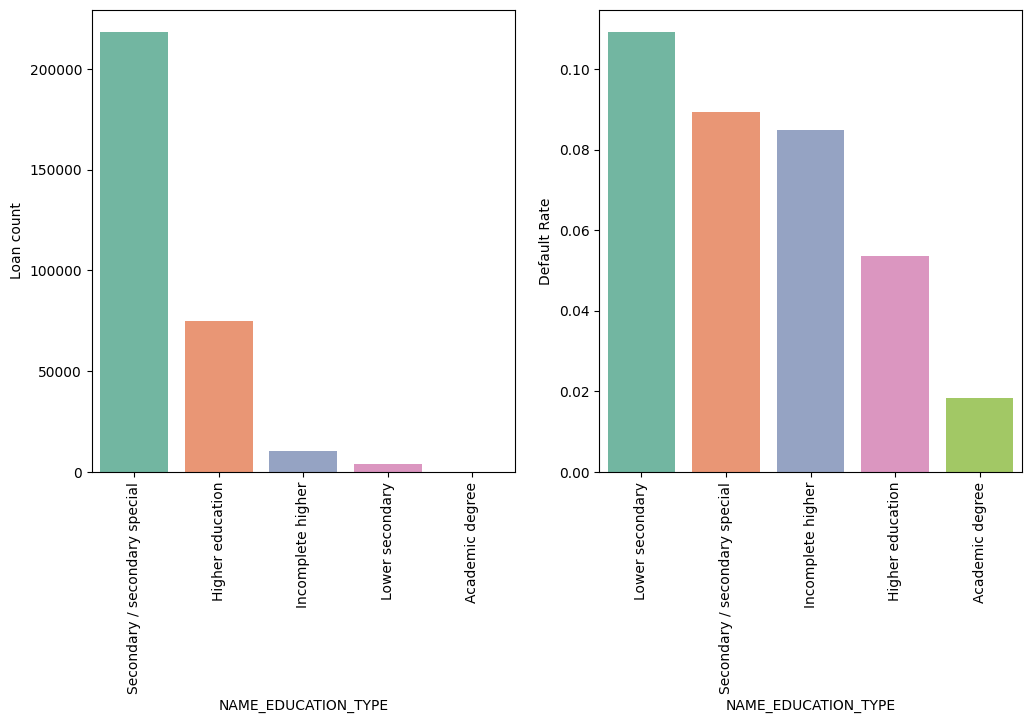

In [44]:
plot_stats('NAME_EDUCATION_TYPE', 90)

Чем выше образование, тем лучше возвратность, очевидно.

# Data Cleaning and Feature Engineering

## Drop the outliers

In [45]:
upper = app_train['AMT_INCOME_TOTAL'].quantile(0.99)
app_train['AMT_INCOME_TOTAL'] = app_train['AMT_INCOME_TOTAL'].clip(upper=upper)

app_train = app_train[app_train['DAYS_EMPLOYED'] != app_train['DAYS_EMPLOYED'].max()]

## Deal with NaNs

In [46]:
# Если у человека нет машины, то, очевидно, у него нет и возраста автомобиля, поэтому просто заменим NaN на 0
app_train.OWN_CAR_AGE.fillna(0, inplace=True)
app_test.OWN_CAR_AGE.fillna(0, inplace=True)

In [47]:
# Сразу же удалим столбцы, в которых слишком большой процент пропусков
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 1]

In [48]:
cols_to_drop = missing_pct.index[missing_pct > 70].tolist()
app_train = app_train.drop(columns=cols_to_drop)
app_test = app_test.drop(columns=cols_to_drop)

target = app_train['TARGET']
app_train.drop(columns=['TARGET'], inplace=True)

num_cols = app_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = app_train.select_dtypes(exclude=['float64', 'int64']).columns.tolist()

In [49]:
from sklearn.impute import SimpleImputer

imp_num = SimpleImputer(strategy='median')
app_train[num_cols] = imp_num.fit_transform(app_train[num_cols])

app_test[num_cols] = imp_num.transform(app_test[num_cols])

imp_cat = SimpleImputer(strategy='most_frequent')
app_train[cat_cols] = imp_cat.fit_transform(app_train[cat_cols].astype(str))
app_test[cat_cols] = imp_cat.transform(app_test[cat_cols].astype(str))

## Imputing NaN values (Вычислительные сложности ....)

Далее мы воспользуемся KNNImputer, который по соседним числовым значениям восстановит нам все NaN-значения

Но перед этим необходимо отнормализовать значения, иначе фичи с большими числами (например, доход в миллионах) будут давить на «близость» соседей

In [50]:
# # Выберем только числовые признаки
# num_cols = app_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
# num_cols.remove('TARGET')
# # num_cols

In [51]:
# len(num_cols + ordinal_enc_cols)

In [52]:
# for df in [app_train, app_test]:
#     df[df.select_dtypes('float64').columns] = df.select_dtypes('float64').astype('float32')
#     df[df.select_dtypes('int64').columns]   = df.select_dtypes('int64').astype('int32')

# app_train.dtypes.value_counts()

In [53]:
# import pandas as pd
# from sklearn.feature_selection import mutual_info_classif
# from sklearn.impute import SimpleImputer

# def compute_mutual_info(df, target_col):
#     """
#     Считает mutual information для всех признаков (числовых и категориальных) относительно таргета.
#     df : pd.DataFrame
#     target_col : str
#     """
#     X = df.drop(columns=[target_col])
#     y = df[target_col]

#     # разделяем на числовые и категориальные
#     num_cols = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns
#     cat_cols = X.select_dtypes(exclude=['int64', 'float64', 'int32', 'float32']).columns

#     # Имьютация
#     X_num = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X[num_cols]),
#                          columns=num_cols, index=X.index)
#     X_cat = pd.DataFrame(SimpleImputer(strategy='most_frequent').fit_transform(X[cat_cols].astype(str)),
#                          columns=cat_cols, index=X.index)

#     # объединяем обратно
#     X_all = pd.concat([X_num, X_cat], axis=1)

#     # маска дискретных колонок
#     discrete_mask = [col in cat_cols for col in X_all.columns]

#     # mutual info
#     mi = mutual_info_classif(X_all, y, discrete_features=discrete_mask, random_state=42)

#     # результат
#     mi_series = pd.Series(mi, index=X_all.columns, name='mutual_info').sort_values(ascending=False)
#     return mi_series.to_frame()

In [54]:
# num_cols = app_train.select_dtypes(include=['int64', 'float64', 'int32', 'float32']).columns.tolist()

In [55]:
# num_cols.sort()
# # num_cols

In [56]:
# # target = app_train['TARGET']
# # app_train.drop(columns=['TARGET'], inplace=True)
# num_cols.remove('AGE_YEARS')

In [57]:
# X_num = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(app_train[num_cols]),
#                          columns=num_cols, index=app_train.index)

In [58]:
# mi = mutual_info_classif(X_num, target, discrete_features=False, random_state=42)

In [59]:
# mi_series = pd.Series(mi, index=X_num.columns, name='mutual_info').sort_values(ascending=False)
# mi_series.to_frame()
# mi_series = mi_series[mi_series > 0.005]

# plt.figure(figsize=(5, 25))
# sns.barplot(x='mutual_info', y=mi_series.index, data=mi_series.reset_index())
# plt.title('Mutual Information with Target')
# plt.show()

In [60]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.impute import KNNImputer

# # target = app_train['TARGET']
# # app_train.drop(columns=['TARGET'], inplace=True)

# KNN_scaler = StandardScaler()
# app_train_scaled = KNN_scaler.fit_transform(app_train[num_cols + ordinal_enc_cols])
# app_test_scaled = KNN_scaler.transform(app_test[num_cols + ordinal_enc_cols])

# KNN_imputer = KNNImputer(n_neighbors=3)
# app_train_imputed = KNN_imputer.fit_transform(app_train_scaled)
# app_test_imputed = KNN_imputer.transform(app_test_scaled)

## Column dtypes and categorical data handling

Далее посмотрим, распределение типов данных в датасете:

In [61]:
# Оставим app_train без изменения, чтобы потом передать катбусту
app_train_catboost = app_train.copy()
app_test_catboost = app_test.copy()


In [62]:
app_train.dtypes.value_counts()

float64    106
object      16
Name: count, dtype: int64

16 колонок в датасете имеют тип "объект" и нам нужно их заэнкодить. Осталось выбрать вариант энкодера

In [63]:
app_train.select_dtypes(include=[object]).apply(pd.Series.nunique).sort_values(ascending=False)

ORGANIZATION_TYPE             58
OCCUPATION_TYPE               19
NAME_TYPE_SUITE                8
NAME_INCOME_TYPE               8
WALLSMATERIAL_MODE             8
WEEKDAY_APPR_PROCESS_START     7
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_EDUCATION_TYPE            5
FONDKAPREMONT_MODE             5
HOUSETYPE_MODE                 4
CODE_GENDER                    3
EMERGENCYSTATE_MODE            3
NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
dtype: int64

In [64]:
app_train.NAME_EDUCATION_TYPE.unique()

array(['Secondary / secondary special', 'Higher education',
       'Incomplete higher', 'Lower secondary', 'Academic degree'],
      dtype=object)

Как мы видим, можно отранжировать типы образования (например, по возрастанию) и каждому типу присвоить свое число.

In [65]:
# Выделим все колонки с категориальными признаками
object_cols = app_train.select_dtypes(include=['object']).columns.tolist()

Далее займемся энкодерами

Фичи, в которых всего два уникальных значения будем кодировать при помощи OrdinalEncoder:

In [66]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc_cols = [
    'NAME_EDUCATION_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'NAME_CONTRACT_TYPE',
    'FLAG_OWN_REALTY',
    'EMERGENCYSTATE_MODE'
]

# Формируем список категорий для 'NAME_EDUCATION_TYPE'
categories = [
    [
        'Lower secondary',
        'Secondary / secondary special',
        'Incomplete higher',
        'Higher education',
        'Academic degree'
    ]
]

# Для остальных колонок получаем уникальные значения в порядке появления
for col in ordinal_enc_cols[1:]:
    cats = list(app_train[col].unique())
    categories.append(cats)

ordinal_enc = OrdinalEncoder(
    categories=categories,
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    dtype=int
)

app_train[ordinal_enc_cols] = ordinal_enc.fit_transform(app_train[ordinal_enc_cols])
app_test[ordinal_enc_cols] = ordinal_enc.fit_transform(app_test[ordinal_enc_cols])

А всё остальное - OneHotEncoderом

In [67]:
one_hot_enc_cols = [
    'ORGANIZATION_TYPE',
    'OCCUPATION_TYPE',
    'NAME_INCOME_TYPE',
    'NAME_TYPE_SUITE',
    'WALLSMATERIAL_MODE',
    'WEEKDAY_APPR_PROCESS_START',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'HOUSETYPE_MODE'
]

app_train = pd.get_dummies(app_train, columns=one_hot_enc_cols)
app_test = pd.get_dummies(app_test, columns=one_hot_enc_cols)

In [68]:
print('После OneHot:')
print('Формат тренировочной выборки: ', app_train.shape)
print('Формат тестовой выборки: ', app_test.shape)

После OneHot:
Формат тренировочной выборки:  (307510, 237)
Формат тестовой выборки:  (48744, 235)


Теперь у нас появились столбцы, которых нет в обеих выборках. Нам поможет метод align()

In [69]:
# Выравнивание - сохранятся только столбцы. имеющиеся в обоих датафреймах
app_train, app_test = app_train.align(app_test, join = 'inner', axis = 1)

print('После align():')
print('Формат тренировочной выборки: ', app_train.shape)
print('Формат тестовой выборки: ', app_test.shape)

# Add target back into the data
app_train['TARGET'] = target

После align():
Формат тренировочной выборки:  (307510, 235)
Формат тестовой выборки:  (48744, 235)


## Polinomial features

Выберем только важные признаки и лишь из них сделаем полиномы, во избежание переобучения:

In [70]:
# Cоздадим новый датафрейм для полиномиальных признаков
poly_features = app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']]
poly_features_test = app_test[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS']]

In [71]:
from sklearn.preprocessing import PolynomialFeatures

# Создадим полиномиальный объект степени 3
poly_transformer = PolynomialFeatures(degree = 3)

# Тренировка полиномиальных признаков
poly_transformer.fit(poly_features)

# Трансформация признаков
poly_features = poly_transformer.transform(poly_features)
poly_features_test = poly_transformer.transform(poly_features_test)
print('Формат полиномиальных признаков: ', poly_features.shape)

Формат полиномиальных признаков:  (307510, 35)


Присвоим признакам имена при помощи метода get_feature_names:


In [72]:
poly_transformer.get_feature_names_out(input_features = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS'])[:15]

array(['1', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'AGE_YEARS',
       'EXT_SOURCE_1^2', 'EXT_SOURCE_1 EXT_SOURCE_2',
       'EXT_SOURCE_1 EXT_SOURCE_3', 'EXT_SOURCE_1 AGE_YEARS',
       'EXT_SOURCE_2^2', 'EXT_SOURCE_2 EXT_SOURCE_3',
       'EXT_SOURCE_2 AGE_YEARS', 'EXT_SOURCE_3^2',
       'EXT_SOURCE_3 AGE_YEARS', 'AGE_YEARS^2'], dtype=object)

Итого 35 полиномиальных и производных признаков. Проверих их корреляцию с таргетом.

In [73]:
# Датафрейм для новых фич
poly_features = pd.DataFrame(poly_features,
                             columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2',
                                                                           'EXT_SOURCE_3', 'AGE_YEARS']))
poly_features_test = pd.DataFrame(poly_features_test,
                                  columns = poly_transformer.get_feature_names_out(['EXT_SOURCE_1', 'EXT_SOURCE_2',
                                                                                'EXT_SOURCE_3', 'AGE_YEARS']))

# Добавим таргет
poly_features_with_TARGET = poly_features.copy()
poly_features_with_TARGET['TARGET'] = target

# Рассчитаем корреляцию
poly_corrs = poly_features_with_TARGET.corr()['TARGET'].sort_values()

# Отобразим признаки с наивысшей корреляцией
print(poly_corrs.head(10))
print(poly_corrs.tail(5))

EXT_SOURCE_2 EXT_SOURCE_3                -0.178014
EXT_SOURCE_1 EXT_SOURCE_2 EXT_SOURCE_3   -0.173867
EXT_SOURCE_2 EXT_SOURCE_3 AGE_YEARS      -0.166366
EXT_SOURCE_2^2 EXT_SOURCE_3              -0.161767
EXT_SOURCE_2 EXT_SOURCE_3^2              -0.158300
EXT_SOURCE_1 EXT_SOURCE_2                -0.152347
EXT_SOURCE_1 EXT_SOURCE_3                -0.150282
EXT_SOURCE_2                             -0.146858
EXT_SOURCE_2 AGE_YEARS                   -0.143552
EXT_SOURCE_1 EXT_SOURCE_2^2              -0.143275
Name: TARGET, dtype: float64
AGE_YEARS     -0.071492
AGE_YEARS^2   -0.069996
AGE_YEARS^3   -0.067779
TARGET         1.000000
1                   NaN
Name: TARGET, dtype: float64


Итак, некоторые признаки показывают более высокую корреляцию, чем исходные. Есть смысл попробовать обучение с ними и без них. Для этого присоединим полиномиальные признаки к основному DF.

In [74]:
# Объединим тренировочные датафреймы
poly_features['SK_ID_CURR'] = app_train['SK_ID_CURR']
app_train_poly = app_train.merge(poly_features, on = 'SK_ID_CURR', how = 'left')

# Объединим тестовые датафреймы
poly_features_test['SK_ID_CURR'] = app_test['SK_ID_CURR']
app_test_poly = app_test.merge(poly_features_test, on = 'SK_ID_CURR', how = 'left')

# Посмотрим формат
print('Тренировочная выборка с полиномиальными признаками: ', app_train_poly.shape)
print('Тестовая выборка с полиномиальными признаками: ', app_test_poly.shape)

Тренировочная выборка с полиномиальными признаками:  (307510, 271)
Тестовая выборка с полиномиальными признаками:  (48744, 270)


# Model Training

## Model evaluation functions

Создадим функцию для подбора гиперпараметров при помощи библиотеки Optuna

In [75]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
from catboost import Pool
from catboost import cv as catboost_cv

def optuna_tune(model_class, param_space_func, X, y, n_trials=60, cv_num=5):
    
    cat_features_indices = [
            i for i, col in enumerate(X.columns) 
            if X[col].dtype in ['object', 'category', 'string']]

    def objective(trial):
        params = param_space_func(trial)
        model = model_class(**params)
        cv = StratifiedKFold(n_splits=cv_num, shuffle=True, random_state=42)

        # Разные стратегии для CatBoost и других моделей
        if model_class.__name__ == 'CatBoostClassifier':
            # Для CatBoost используем встроенную кросс-валидацию
            pool = Pool(
                data=X,
                label=y,
                cat_features=cat_features_indices if cat_features_indices else None
            )
            
            # Кросс-валидация CatBoost
            cv_results = catboost_cv(
                pool=pool,
                params=params,
                fold_count=cv_num,
                partition_random_seed=42,
                shuffle=True,
                stratified=True,
                verbose=False,
            )

            # Вычисляем средний AUC
            score = cv_results['test-AUC-mean'].mean()

        else:
            score = cross_val_score(
                model, X, y,
                cv=cv,
                scoring='roc_auc',
                n_jobs=-1,
                verbose=1
            ).mean()
        
        return score

    study = optuna.create_study(direction='maximize', storage="sqlite:///optuna_logs.db", study_name=model_class.__name__, load_if_exists=True)
    study.optimize(objective, n_trials=n_trials)
    print("Лучшие параметры:", study.best_params)

    # Fit the best model with the entire dataset for easy production use
    best_model = model_class(**study.best_params)
    if model_class.__name__ == 'CatBoostClassifier':
        best_model.fit(X, y, cat_features=cat_features_indices)
    else:
         best_model.fit(X, y)
    
    return study, best_model

## 1) Get Baseline - Logistic Regression

Разделим app_train на тренировочную и тестовую выборку

In [76]:
from sklearn.model_selection import train_test_split

# app_train.drop(columns=['SK_ID_CURR'], inplace=True)
# app_test.drop(columns=['SK_ID_CURR'], inplace=True)

# app_train.drop(columns=['TARGET'], inplace=True)

X_train, X_val, y_train, y_val = train_test_split(app_train, target, test_size=0.2, random_state=42, stratify=target)
X_kaggle = app_test

# Новый датасет для CatBoost Classifier (в нем нет предварительного энкодинга)
X_train_catboost, X_val_catboost, y_train_catboost, y_val_catboost = train_test_split(app_train_catboost, target, test_size=0.2, random_state=42, stratify=target)
X_kaggle_catboost = app_test_catboost

Создадим функцию для построения кривой ROC и создания csv-файла, который позже пойдет в Kaggle для сабмита

In [77]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

def get_score(pipeline, csv_name, X_kaggle, X_val):

    y_kaggle_proba = pipeline.predict_proba(X_kaggle)[:, 1]
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]

    # Make submission-file for Kaggle
    submission = pd.DataFrame({'SK_ID_CURR': X_kaggle['SK_ID_CURR'], 'TARGET': y_kaggle_proba})
    submission['SK_ID_CURR'] = submission['SK_ID_CURR'].astype(int)
    submission.to_csv(csv_name, index=False)

    # Plotting ROC-curve
    fpr, tpr, _ = roc_curve(y_val,  y_val_proba)
    auc = roc_auc_score(y_val, y_val_proba)

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=f'AUC = {auc:.4f}', color='blue')
    plt.plot([0, 1], [0, 1], linestyle='--', color='green') # lame-classifier
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.show()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Pipeline: scaler + logistic regression
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(
                                  penalty="elasticnet",
                                  solver="saga",
                                  l1_ratio=0.9,
                                  max_iter=30,
                                  verbose=0,
                                  random_state=42
                                  ))
])

# Learning....
pipeline_logreg.fit(X_train, y_train)

get_score(pipeline_logreg, '../Kaggle Submissions/submission_logreg.csv', X_kaggle, X_val)

Выполнение кода заняло 16 секунд

Kaggle Score = 0.69638

## 2) Decision Trees

Проделаем то же самое с простейшим "деревянным" алгоритмом

In [ ]:
from sklearn.tree import DecisionTreeClassifier

def decision_tree_param_space(trial):
    return {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

# Optuna tuning
study, best_decision_tree= optuna_tune(DecisionTreeClassifier, decision_tree_param_space, X_train, y_train, n_trials=10, cv_num=5)

# Get AUC and Kaggle-score
get_score(best_decision_tree, '../Kaggle Submissions/submission_decision_tree.csv', X_kaggle, X_val)


Подбор гиперпараметров занял 3 минуты

Kaggle Score = 0.70369

## 3) Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 800),
        "max_depth": trial.suggest_int("max_depth", 5, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

# Optuna tuning
study, best_random_forest = optuna_tune(RandomForestClassifier, random_forest_param_space, X_train, y_train, n_trials=1, cv_num=5)

# Get AUC and Kaggle-score
get_score(best_random_forest, '../Kaggle Submissions/submission_random_forest.csv', X_kaggle, X_val)

Kaggle-score = 0,71350

## 4) CatBoost

В дальнейшем можно попробовать применить catboost на данных без предварительного энкодинга, ибо его алгоритмы должны справиться с этим лучше

In [78]:
from catboost import CatBoostClassifier

def catboost_param_space(trial):
    return {
        "iterations": trial.suggest_int("iterations", 300, 500),
        "depth": trial.suggest_int("depth", 3, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0, 1),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        "bootstrap_type": "Bernoulli",
        "verbose": 0,
        "random_state": 42
    }


# Optuna tuning
study, best_catboost = optuna_tune(CatBoostClassifier, catboost_param_space, X_train_catboost, y_train_catboost, n_trials=15, cv_num=5)

# Get AUC and Kaggle-score
get_score(best_catboost, '../Kaggle Submissions/submission_catboost.csv', X_kaggle_catboost, X_val_catboost)

[I 2025-12-28 23:34:11,411] A new study created in RDB with name: CatBoostClassifier


Training on fold [0/5]

bestTest = 0.7581297304
bestIteration = 387

Training on fold [1/5]

bestTest = 0.7577571243
bestIteration = 392

Training on fold [2/5]

bestTest = 0.7520314543
bestIteration = 389

Training on fold [3/5]

bestTest = 0.7480881893
bestIteration = 392

Training on fold [4/5]


[I 2025-12-28 23:36:15,581] Trial 0 finished with value: 0.7471608898504637 and parameters: {'iterations': 393, 'depth': 4, 'learning_rate': 0.05051283521273299, 'l2_leaf_reg': 5.1952639332739885, 'border_count': 134, 'random_strength': 0.1544140138315685}. Best is trial 0 with value: 0.7471608898504637.



bestTest = 0.7561773924
bestIteration = 392

Training on fold [0/5]

bestTest = 0.7453708293
bestIteration = 449

Training on fold [1/5]

bestTest = 0.7436842109
bestIteration = 448

Training on fold [2/5]

bestTest = 0.7383201535
bestIteration = 449

Training on fold [3/5]

bestTest = 0.7354107987
bestIteration = 449

Training on fold [4/5]


[I 2025-12-28 23:38:13,435] Trial 1 finished with value: 0.7286591870445092 and parameters: {'iterations': 450, 'depth': 3, 'learning_rate': 0.01170072628591265, 'l2_leaf_reg': 3.3243093752242103, 'border_count': 57, 'random_strength': 0.782718859662564}. Best is trial 0 with value: 0.7471608898504637.


...


bestTest = 0.7553609864
bestIteration = 323

Training on fold [0/5]

bestTest = 0.7609952399
bestIteration = 317

Training on fold [1/5]

bestTest = 0.7587071417
bestIteration = 286

Training on fold [2/5]

bestTest = 0.7553228336
bestIteration = 281

Training on fold [3/5]

bestTest = 0.7498522624
bestIteration = 246

Training on fold [4/5]


[I 2025-12-28 23:52:22,583] Trial 6 finished with value: 0.7521720412914079 and parameters: {'iterations': 351, 'depth': 7, 'learning_rate': 0.11325930915355141, 'l2_leaf_reg': 9.802580564138852, 'border_count': 166, 'random_strength': 0.655575123135474}. Best is trial 6 with value: 0.7521720412914079.



bestTest = 0.7604340289
bestIteration = 350

Training on fold [0/5]

bestTest = 0.76030711
bestIteration = 284

Training on fold [1/5]

bestTest = 0.7595303038
bestIteration = 267

Training on fold [2/5]


[W 2025-12-28 23:54:04,600] Trial 7 failed with parameters: {'iterations': 366, 'depth': 6, 'learning_rate': 0.15005280894438092, 'l2_leaf_reg': 4.87801728691032, 'border_count': 202, 'random_strength': 0.8694831019937151} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/Users/uralgimazov/Library/Python/3.9/lib/python/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/8r/46ncjmbn5rq0s4d0hqmk4f440000gn/T/ipykernel_47393/1997889243.py", line 27, in objective
    cv_results = catboost_cv(
  File "/Users/uralgimazov/Library/Python/3.9/lib/python/site-packages/catboost/core.py", line 6980, in cv
    return _cv(
  File "_catboost.pyx", line 5880, in _catboost._cv
  File "_catboost.pyx", line 5912, in _catboost._cv
KeyboardInterrupt
[W 2025-12-28 23:54:04,622] Trial 7 failed with value None.


KeyboardInterrupt: 

Kaggle-score = 0,73924

# Export to the PROD

Из всех моделей осталось выбрать наилучшую по Kaggle-score и дальше через FastAPI & Streamlit UI сделать полноценное приложение.

In [ ]:
import joblib

# Save the production model
joblib.dump(pipeline_logreg, "../models/pipeline_logreg.joblib")
joblib.dump(best_decision_tree, "../models/best_decision_tree.joblib")
joblib.dump(best_random_forest, "../models/best_random_forest.joblib")
joblib.dump(best_catboost, "../models/best_catboost.joblib")